In [1]:
import xarray as xr
import xagg
import geopandas as gpd
import numpy as np
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt
import warnings
import seaborn as sns
sns.set_style('white')

# Combining 2m Temperature Absolute Error at 24 hour lead time with Maryland Counties

## Read in forecast, analysis, and climatology data and compute anomalies

In [2]:
# Forecast (00z initialization time, 24 hour lead time)
fc_files = sorted(glob.glob('/glade/derecho/scratch/dcalhoun/ecmwf/ifs/fc/0.125/t2m/00/24/2023/07/*.nc'))
ds_fc = xr.open_mfdataset(fc_files)

# Analysis
an_files = sorted(glob.glob('/glade/derecho/scratch/dcalhoun/ecmwf/ifs/an/0.125/t2m/2023/07/*/*.nc'))
ds_an = xr.open_mfdataset(an_files)

# Climatology
clim_file = '/glade/derecho/scratch/dcalhoun/ecmwf/era5/era5_2t_climatology_1991_2020_sorted.nc'
ds_clim = xr.open_dataset(clim_file)

# Ensure all times present in both fc and an
common_times = np.intersect1d(ds_fc['t2m'].time.values, ds_an['t2m'].time.values)
ds_fc = ds_fc.sel(time=common_times)
ds_an = ds_an.sel(time=common_times)

ds_fc = ds_fc.sel(time=~((ds_fc.time.dt.month == 2) & (ds_fc.time.dt.day == 29)))
ds_an = ds_an.sel(time=~((ds_an.time.dt.month == 2) & (ds_an.time.dt.day == 29)))

# Interpolate the climatology to the same grid as the forecast and analysis
ds_clim = ds_clim.sel(latitude=slice(ds_fc.latitude.min(), ds_fc.latitude.max()), longitude=slice(ds_fc.longitude.min(), ds_fc.longitude.max())).interp(latitude = ds_fc.latitude.values, longitude = ds_fc.longitude.values, method='nearest')

# Calculate anomalies
ds_clim = ds_clim.sel(time=pd.to_datetime(ds_fc.time.dt.strftime('2017-%m-%d')).dayofyear) # align climatology to forecast data
ds_fc['t2m'] = (['time', 'latitude', 'longitude'], ds_fc['t2m'].values - ds_clim['2t'].values)
ds_an['t2m'] = (['time', 'latitude', 'longitude'], ds_an['t2m'].values - ds_clim['2t'].values)

In [3]:
ds_fc

<xarray.Dataset> Size: 2MB
Dimensions:    (time: 30, latitude: 81, longitude: 121)
Coordinates:
  * longitude  (longitude) float32 484B -85.0 -84.88 -84.75 ... -70.12 -70.0
  * latitude   (latitude) float32 324B 45.0 44.88 44.75 ... 35.25 35.12 35.0
  * time       (time) datetime64[ns] 240B 2023-07-02 2023-07-03 ... 2023-07-31
Data variables:
    t2m        (time, latitude, longitude) float64 2MB 5.558 5.467 ... 0.09521
Attributes:
    Conventions:  CF-1.6
    history:      2024-11-24 03:29:47 GMT by grib_to_netcdf-2.25.0: grib_to_n...

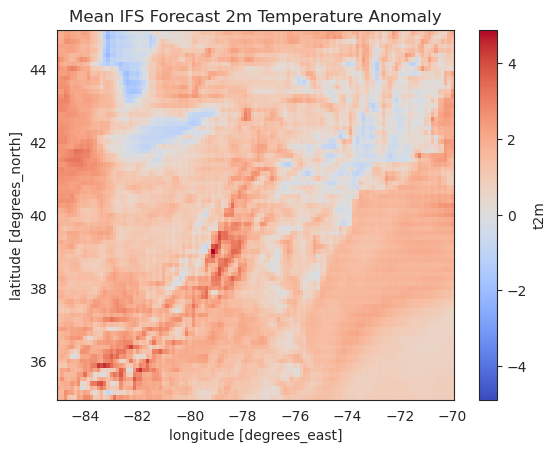

In [4]:
ds_fc.t2m.mean(axis=0).plot(cmap='coolwarm')
plt.title('Mean IFS Forecast 2m Temperature Anomaly')
plt.show()

In [5]:
ds_an

<xarray.Dataset> Size: 2MB
Dimensions:    (time: 30, latitude: 81, longitude: 121)
Coordinates:
  * longitude  (longitude) float32 484B -85.0 -84.88 -84.75 ... -70.12 -70.0
  * latitude   (latitude) float32 324B 45.0 44.88 44.75 ... 35.25 35.12 35.0
  * time       (time) datetime64[ns] 240B 2023-07-02 2023-07-03 ... 2023-07-31
Data variables:
    t2m        (time, latitude, longitude) float64 2MB 6.813 6.697 ... -0.06523
Attributes:
    Conventions:  CF-1.6
    history:      2024-11-30 22:14:05 GMT by grib_to_netcdf-2.25.0: grib_to_n...

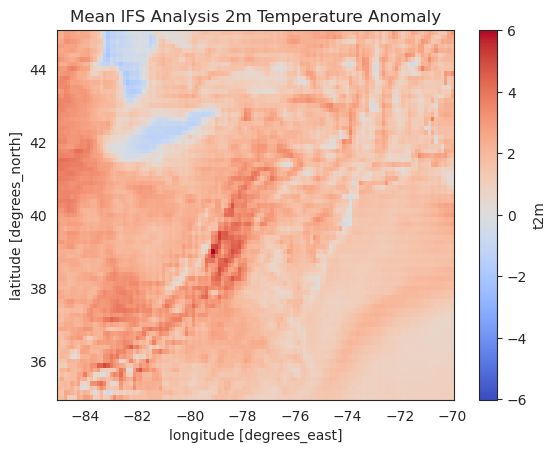

In [6]:
ds_an.t2m.mean(axis=0).plot(cmap='coolwarm')
plt.title('Mean IFS Analysis 2m Temperature Anomaly')
plt.show()

## Calculate Absolute Error

In [7]:
ds_abs_error = xr.Dataset({
                't2m_abs_error': (['time', 'latitude','longitude'], abs(ds_fc.t2m - ds_an.t2m).values)
                },
                coords = {
                    'time':(['time'], ds_fc.time.values),
                    'latitude' : (['latitude'], ds_fc.latitude.values),
                    'longitude' : (['longitude'], ds_fc.longitude.values)
                })      

In [8]:
ds_abs_error

<xarray.Dataset> Size: 2MB
Dimensions:        (time: 30, latitude: 81, longitude: 121)
Coordinates:
  * time           (time) datetime64[ns] 240B 2023-07-02 ... 2023-07-31
  * latitude       (latitude) float32 324B 45.0 44.88 44.75 ... 35.25 35.12 35.0
  * longitude      (longitude) float32 484B -85.0 -84.88 -84.75 ... -70.12 -70.0
Data variables:
    t2m_abs_error  (time, latitude, longitude) float64 2MB 1.254 1.23 ... 0.1604

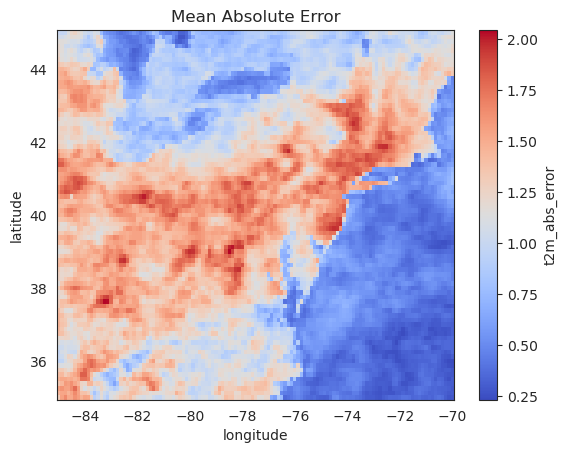

In [9]:
ds_abs_error.t2m_abs_error.mean(axis=0).plot(cmap='coolwarm')
plt.title('Mean Absolute Error')
plt.show()

## Aggregate

In [10]:
# Read in the shapefile
shapefile_path = '/glade/derecho/scratch/dcalhoun/census/shapefiles/nhgis0001_shapefile_tl2023_us_tract_2023'
gdf = gpd.read_file(shapefile_path, columns=['GEOID', 'STATEFP', 'geometry']).to_crs('WGS84')
gdf.head()

,GEOID,STATEFP,geometry
0,01001020100,01,"POLYGON ((-86.47886 32.48934, -86.47903 32.488..."
1,01001020200,01,"POLYGON ((-86.46735 32.45931, -86.46737 32.459..."
2,01001020300,01,"POLYGON ((-86.45068 32.46034, -86.45085 32.460..."
3,01001020400,01,"POLYGON ((-86.43599 32.48021, -86.43595 32.480..."
4,01001020501,01,"POLYGON ((-86.41167 32.4598, -86.41167 32.4562..."


In [11]:
# Maryland only
gdf_md = gdf[gdf['STATEFP'] == '24'][['GEOID', 'geometry']].reset_index(drop=True)
gdf_md

,GEOID,geometry
0,24001000100,"POLYGON ((-78.34283 39.72226, -78.34273 39.722..."
1,24001000200,"POLYGON ((-78.61336 39.53717, -78.61337 39.537..."
2,24001000500,"POLYGON ((-78.71741 39.63624, -78.71742 39.636..."
3,24001000600,"POLYGON ((-78.71741 39.63624, -78.71742 39.636..."
4,24001000700,"POLYGON ((-78.7384 39.62725, -78.73849 39.6271..."
...,...,...
1458,24510280402,"POLYGON ((-76.68627 39.29922, -76.68623 39.298..."
1459,24510280403,"POLYGON ((-76.69293 39.28147, -76.69333 39.281..."
1460,24510280404,"POLYGON ((-76.68677 39.28723, -76.68675 39.286..."
1461,24510280500,"POLYGON ((-76.59441 39.29837, -76.59436 39.297..."


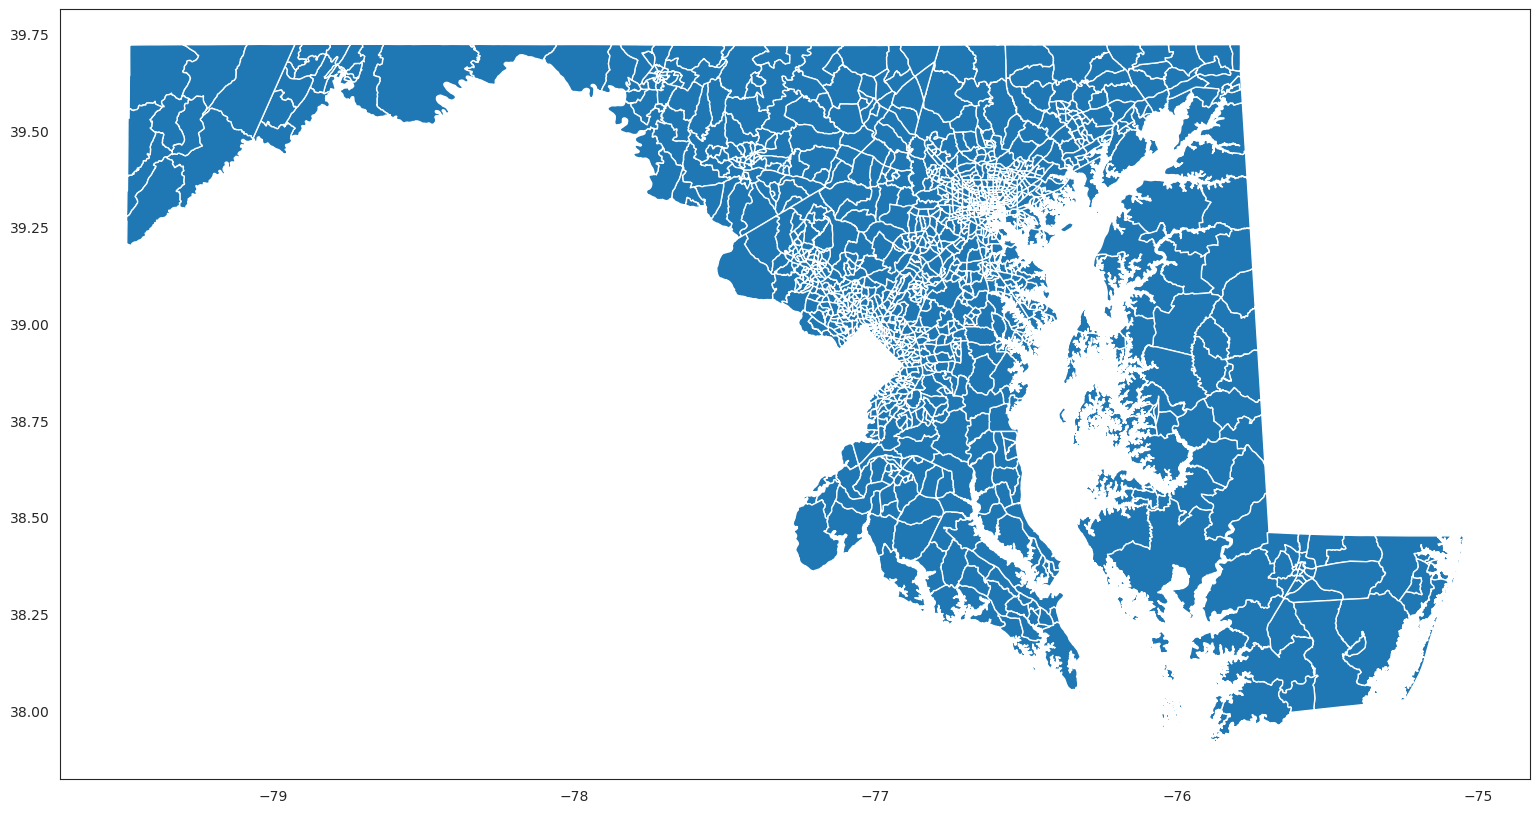

In [15]:
fig, ax = plt.subplots(1, figsize=(20,10))
gdf_md.plot(ax=ax)
plt.show()

In [48]:
# Aggregate
dfs = []
dates = pd.to_datetime(ds_abs_error.time.values)
for i, date in enumerate(dates):
    day = date.strftime('%d')
    hour = date.strftime('%H')
    dirname = '/glade/derecho/scratch/dcalhoun/aggregated/tract/Maryland/ifs/0.125/t2m/00/24/2023/07'
    os.makedirs(dirname, exist_ok=True)
    filename = os.path.join(dirname, f'ifs_abs_error_t2m_2023_07_{day}_{hour}z.csv')
    weightmap = xagg.pixel_overlaps(ds_abs_error.sel(time=date), gdf_md, silent=True)
    aggregated = xagg.aggregate(ds_abs_error.sel(time=date), weightmap, silent=True)
    df = aggregated.to_dataframe()
    df['time'] = date.strftime('%Y-%m-%d-%H')
    df.reset_index(inplace=True, drop=True)
    cols = df.columns.tolist()
    df = df[cols[0:1] + cols[-1:] + cols[1:-1]] # Reorder columns
    df.to_csv(filename)
    dfs.append(df)
dfs[0]

,GEOID,time,t2m_abs_error
0,24001000100,2023-07-02-00,1.192509
1,24001000200,2023-07-02-00,1.428111
2,24001000500,2023-07-02-00,2.012599
3,24001000600,2023-07-02-00,2.012599
4,24001000700,2023-07-02-00,2.012599
...,...,...,...
1458,24510280402,2023-07-02-00,0.772360
1459,24510280403,2023-07-02-00,0.735196
1460,24510280404,2023-07-02-00,0.748836
1461,24510280500,2023-07-02-00,1.019350


In [69]:
df_error = pd.concat(dfs.copy()).reset_index(drop=True)

In [71]:
df_error.groupby('GEOID').describe()

t2m_abs_error                                                    \
                    count      mean       std       min       25%       50%   
GEOID                                                                         
24001000100          30.0  1.478105  0.863587  0.083850  0.735184  1.408297   
24001000200          30.0  1.496808  0.924814  0.038541  0.713537  1.362363   
24001000500          30.0  1.529981  0.997755  0.031471  0.704241  1.507588   
24001000600          30.0  1.529981  0.997755  0.031471  0.704241  1.507588   
24001000700          30.0  1.529981  0.997755  0.031471  0.704241  1.507588   
...                   ...       ...       ...       ...       ...       ...   
24510280402          30.0  1.323765  0.983709  0.197215  0.688559  1.071299   
24510280403          30.0  1.333061  1.021949  0.175705  0.653774  1.020090   
24510280404          30.0  1.329649  1.007459  0.183600  0.666540  1.032658   
24510280500          30.0  1.261988  0.856108  0.218570  0.657235  0.993850   
24510280600          30.0  1.261988  0.856108  0.218570  0.657235  0.993850   

                                 
                  75%       max  
GEOID                            
24001000100  2.095413  3.132527  
24001000200  2.264606  3.592697  
24001000500  2.313932  3.849735  
24001000600  2.313932  3.849735  
24001000700  2.313932  3.849735  
...               ...       ...  
24510280402  1.741844  4.883959  
24510280403  1.694211  5.045602  
24510280404  1.701636  4.986278  
24510280500  1.711645  3.809696  
24510280600  1.711645  3.809696  

[1463 rows x 8 columns]

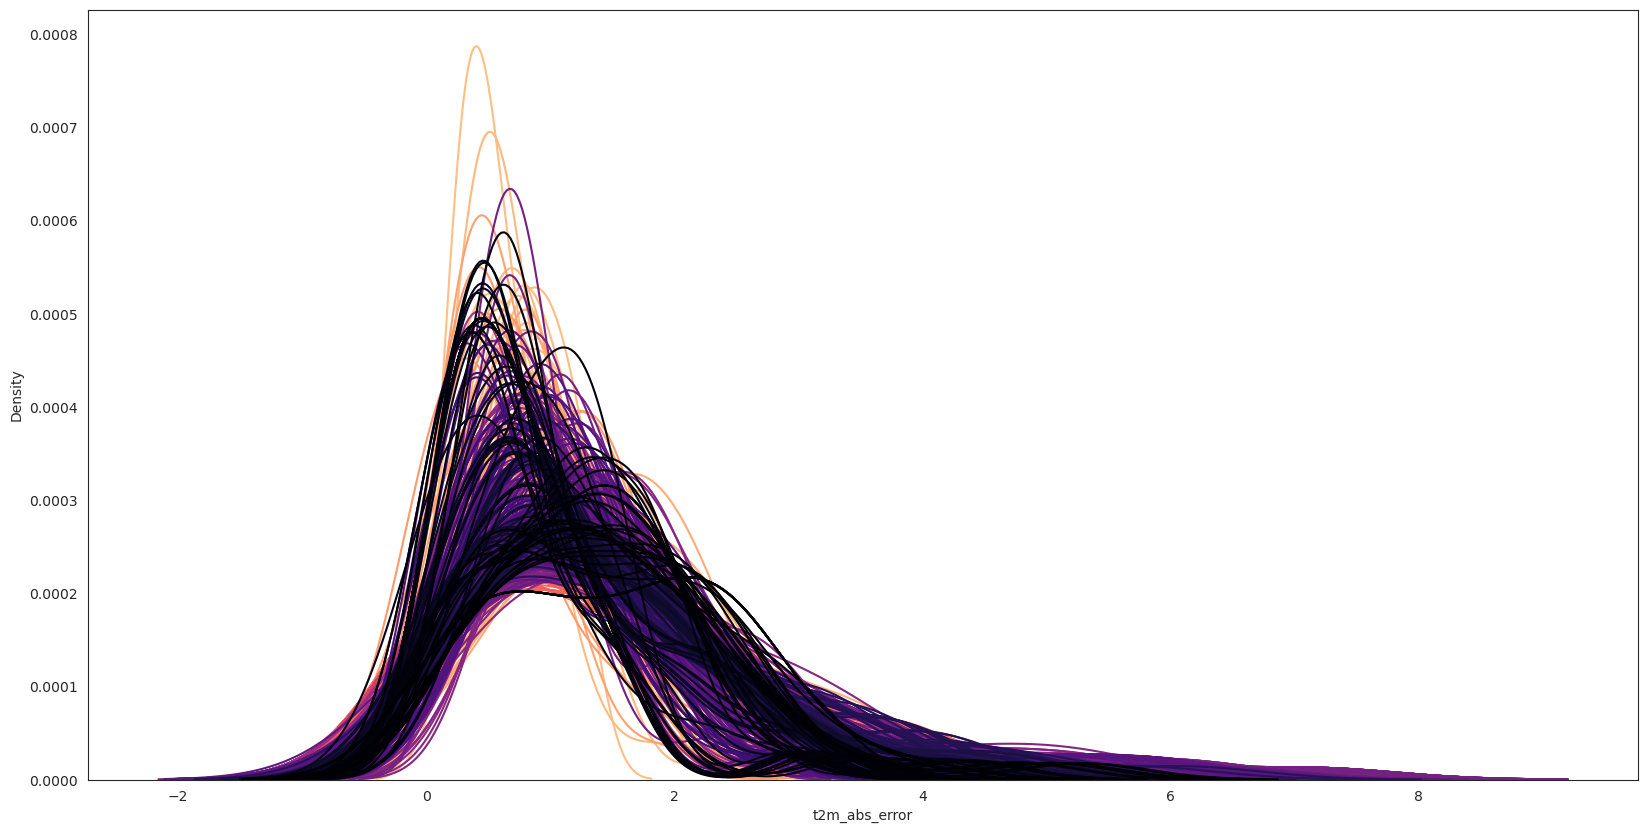

In [83]:
fig, ax = plt.subplots(1, figsize=(20,10))
sns.set_palette('magma', 1463)
sns.kdeplot(data=df_error, hue='GEOID', x='t2m_abs_error', legend=False, ax=ax)
plt.show()

## Get Census Variables

In [2]:
# Read in the census data
census_files = sorted(glob.glob('/glade/derecho/scratch/dcalhoun/census/data/acs_5yr_2023/tract/Maryland/*.csv'))
dataframes = []
df = None
for i, census_file in enumerate(census_files):
    if i != len(census_files) - 1:
        df = pd.read_csv(census_file)
        ncols = len(df.columns)
        df = pd.read_csv(census_file, usecols=range(ncols - 5))
        dataframes.append(df)
    else:
        df = pd.read_csv(census_file)
        dataframes.append(df)
df_census = pd.concat(dataframes, axis=1)

# Clean up the census data
df_census.drop(columns=['Unnamed: 0'], inplace=True) # Drop duplicate index column
df_census['GEOID'] = df_census['GEO_ID'].str.slice(-11) # Extract the shortened GEOID from the GEO_ID column
df_census.drop(columns=['GEO_ID'], inplace=True) # Drop the original GEO_ID column
cols = df_census.columns.tolist()
new_order = cols[-3:] + cols[:-3]
df_census = df_census[new_order] # Reorder columns
df_census.rename(columns={'state': 'STATEFP', 'county': 'COUNTYFP', 'tract': 'TRACTFP'}, inplace=True) # Rename columns

# Split estimates and margins of error into separate DataFrames
retain_columns = ['GEOID', 'NAME', 'STATEFP', 'COUNTYFP', 'TRACTFP']
df_census_est = df_census[[col for col in df_census.columns if col not in retain_columns and col.endswith('E')]].copy()
df_census_moe = df_census[[col for col in df_census.columns if col not in retain_columns and col.endswith('M')]].copy()
df_census_est.columns = df_census_est.columns.str[:-1]
df_census_moe.columns = df_census_moe.columns.str[:-1]
df_census_est = pd.concat([df_census[retain_columns], df_census_est], axis=1)
df_census_moe = pd.concat([df_census[retain_columns], df_census_moe], axis=1)

df_census_est.head()

,GEOID,NAME,STATEFP,COUNTYFP,TRACTFP,B01001_001,B01001_002,B01001_003,B01001_004,B01001_005,...,B23025_007,B25001_001,B25002_001,B25002_002,B25002_003,B25003_001,B25003_002,B25003_003,B25064_001,B25077_001
0,24001000100,Census Tract 1; Allegany County; Maryland,24,1,100,6403,3225,184,75,387,...,1465,2142,2142,1452,690,1452,1145,307,-666666666,190700
1,24001000200,Census Tract 2; Allegany County; Maryland,24,1,200,2703,1444,73,243,142,...,2318,1608,1608,1352,256,1352,1189,163,3501,170400
2,24001000500,Census Tract 5; Allegany County; Maryland,24,1,500,5248,2739,171,192,195,...,1254,1161,1161,827,334,827,495,332,-666666666,107600
3,24001000600,Census Tract 6; Allegany County; Maryland,24,1,600,5268,2537,71,218,221,...,1101,1516,1516,1305,211,1305,896,409,-666666666,127000
4,24001000700,Census Tract 7; Allegany County; Maryland,24,1,700,4712,2351,134,128,242,...,1265,1749,1749,1448,301,1448,625,823,-666666666,119500


## Combine error and census estimates

In [50]:
joined_dfs = []
for df in dfs:
    joined = pd.concat([df.copy().set_index('GEOID'), df_census_est.copy().set_index('GEOID')], axis=1)
    joined_dfs.append(joined)
joined_df = pd.concat(joined_dfs)
joined_df.head()

,time,t2m_abs_error,NAME,STATEFP,COUNTYFP,TRACTFP,B01001_001,B01001_002,B01001_003,B01001_004,...,B23025_007,B25001_001,B25002_001,B25002_002,B25002_003,B25003_001,B25003_002,B25003_003,B25064_001,B25077_001
GEOID,,,,,,,,,,,,,,,,,,,,,
24001000100,2023-07-02-00,1.192509,Census Tract 1; Allegany County; Maryland,24,1,100,6403,3225,184,75,...,1465,2142,2142,1452,690,1452,1145,307,-666666666,190700
24001000200,2023-07-02-00,1.428111,Census Tract 2; Allegany County; Maryland,24,1,200,2703,1444,73,243,...,2318,1608,1608,1352,256,1352,1189,163,3501,170400
24001000500,2023-07-02-00,2.012599,Census Tract 5; Allegany County; Maryland,24,1,500,5248,2739,171,192,...,1254,1161,1161,827,334,827,495,332,-666666666,107600
24001000600,2023-07-02-00,2.012599,Census Tract 6; Allegany County; Maryland,24,1,600,5268,2537,71,218,...,1101,1516,1516,1305,211,1305,896,409,-666666666,127000
24001000700,2023-07-02-00,2.012599,Census Tract 7; Allegany County; Maryland,24,1,700,4712,2351,134,128,...,1265,1749,1749,1448,301,1448,625,823,-666666666,119500


In [51]:
joined_df.describe()

,t2m_abs_error,STATEFP,COUNTYFP,TRACTFP,B01001_001,B01001_002,B01001_003,B01001_004,B01001_005,B01001_006,...,B23025_007,B25001_001,B25002_001,B25002_002,B25002_003,B25003_001,B25003_002,B25003_003,B25064_001,B25077_001
count,43890.000000,44250.0,44250.000000,44250.000000,44250.000000,44250.000000,44250.000000,44250.000000,44250.000000,44250.000000,...,44250.000000,44250.000000,44250.000000,44250.000000,44250.000000,44250.000000,44250.000000,44250.000000,4.425000e+04,4.425000e+04
mean,1.337548,24.0,87.674576,557185.317966,4183.551186,2035.307797,124.009492,131.003390,138.297627,83.012203,...,1102.105763,1725.784407,1725.784407,1586.108475,139.675932,1586.108475,1070.306441,515.802034,-4.293622e+07,-1.948918e+07
std,1.049817,0.0,167.246365,276060.484799,1789.090591,901.766520,96.974410,99.882648,104.636453,68.112800,...,559.143989,797.826420,797.826420,661.401883,435.573485,661.401883,584.729945,482.733923,1.636531e+08,1.134842e+08
min,0.001246,24.0,1.000000,100.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-6.666667e+08,-6.666667e+08
25%,0.579863,24.0,5.000000,400200.000000,2884.000000,1385.000000,57.000000,60.000000,58.000000,32.000000,...,733.000000,1226.000000,1226.000000,1114.000000,38.000000,1114.000000,649.000000,155.000000,1.222000e+03,2.671000e+05
50%,1.091027,24.0,31.000000,700818.000000,4023.000000,1943.000000,102.000000,110.000000,117.000000,69.000000,...,1047.000000,1643.000000,1643.000000,1526.000000,84.000000,1526.000000,1039.000000,371.000000,1.651000e+03,3.677000e+05
75%,1.778157,24.0,33.000000,800103.000000,5346.000000,2611.000000,168.000000,179.000000,195.000000,119.000000,...,1400.000000,2157.000000,2157.000000,2013.000000,160.000000,2013.000000,1448.000000,737.000000,2.082000e+03,4.862000e+05
max,7.088892,24.0,510.000000,990200.000000,14041.000000,7159.000000,634.000000,814.000000,687.000000,525.000000,...,8927.000000,12920.000000,12920.000000,4852.000000,11721.000000,4852.000000,3930.000000,4625.000000,3.501000e+03,2.000001e+06


In [52]:
joined_df['Population Quartile'] = pd.qcut(joined_df['B01001_001'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])

joined_df['Percent White'] = joined_df['B02001_002'] / joined_df['B02001_001'] * 100
joined_df['Percent Black'] = joined_df['B02001_003'] / joined_df['B02001_001'] * 100
joined_df['Percent Below Poverty'] = joined_df['B17001_002']/joined_df['B17001_001']

joined_df['Percent White Quartile'] = pd.qcut(joined_df['Percent White'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])
joined_df['Percent Black Quartile'] = pd.qcut(joined_df['Percent Black'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])
joined_df['Percent Below Poverty Quartile'] = pd.qcut(joined_df['Percent Below Poverty'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])

ValueError: cannot reindex on an axis with duplicate labels

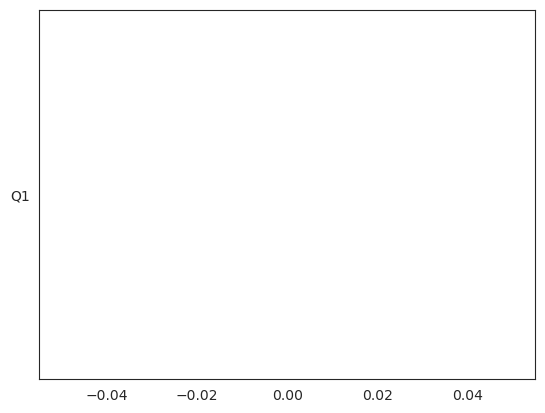

In [53]:
sns.boxplot(data=joined_df, y='Population Quartile', x='t2m_abs_error')
plt.title('Boxplots of t2m_abs_error by Population Quartiles')
plt.ylabel('Quartiles of Population')
plt.xlabel('t2m_abs_error')
plt.show()

sns.boxplot(data=joined_df, y='Percent Below Poverty Quartile', x='t2m_abs_error')
plt.title('Boxplots of t2m_abs_error by Percent Below Poverty Quartiles')
plt.ylabel('Quartiles of Percent Below Poverty')
plt.xlabel('t2m_abs_error')
plt.show()

sns.boxplot(data=joined_df, y='time', x='t2m_abs_error')
plt.title('Boxplots of t2m_abs_error by time')
plt.ylabel('time')
plt.xlabel('t2m_abs_error')
plt.show()

# Combine with shapefiles for plotting

In [54]:
gdfs = []
for df in dfs:
    gdf = pd.concat([df.copy().set_index('GEOID'), df_census_est.copy().set_index('GEOID'), gdf_md.copy().set_index('GEOID')], axis=1)
    gdfs.append(gdf)
gdf_error = gpd.GeoDataFrame(pd.concat(gdfs))
gdf_error

,time,t2m_abs_error,NAME,STATEFP,COUNTYFP,TRACTFP,B01001_001,B01001_002,B01001_003,B01001_004,...,B25001_001,B25002_001,B25002_002,B25002_003,B25003_001,B25003_002,B25003_003,B25064_001,B25077_001,geometry
GEOID,,,,,,,,,,,,,,,,,,,,,
24001000100,2023-07-02-00,1.192509,Census Tract 1; Allegany County; Maryland,24,1,100,6403,3225,184,75,...,2142,2142,1452,690,1452,1145,307,-666666666,190700,"POLYGON ((-78.34283 39.72226, -78.34273 39.722..."
24001000200,2023-07-02-00,1.428111,Census Tract 2; Allegany County; Maryland,24,1,200,2703,1444,73,243,...,1608,1608,1352,256,1352,1189,163,3501,170400,"POLYGON ((-78.61336 39.53717, -78.61337 39.537..."
24001000500,2023-07-02-00,2.012599,Census Tract 5; Allegany County; Maryland,24,1,500,5248,2739,171,192,...,1161,1161,827,334,827,495,332,-666666666,107600,"POLYGON ((-78.71741 39.63624, -78.71742 39.636..."
24001000600,2023-07-02-00,2.012599,Census Tract 6; Allegany County; Maryland,24,1,600,5268,2537,71,218,...,1516,1516,1305,211,1305,896,409,-666666666,127000,"POLYGON ((-78.71741 39.63624, -78.71742 39.636..."
24001000700,2023-07-02-00,2.012599,Census Tract 7; Allegany County; Maryland,24,1,700,4712,2351,134,128,...,1749,1749,1448,301,1448,625,823,-666666666,119500,"POLYGON ((-78.7384 39.62725, -78.73849 39.6271..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24035990200,NaN,NaN,Census Tract 9902; Queen Anne's County; Maryland,24,35,990200,5605,2680,265,163,...,0,0,0,0,0,0,0,1175,-666666666,None
24037990000,NaN,NaN,Census Tract 9900; St. Mary's County; Maryland,24,37,990000,2607,1298,135,137,...,0,0,0,0,0,0,0,2413,-666666666,None
24039990100,NaN,NaN,Census Tract 9901; Somerset County; Maryland,24,39,990100,0,0,0,0,...,0,0,0,0,0,0,0,1552,-666666666,None


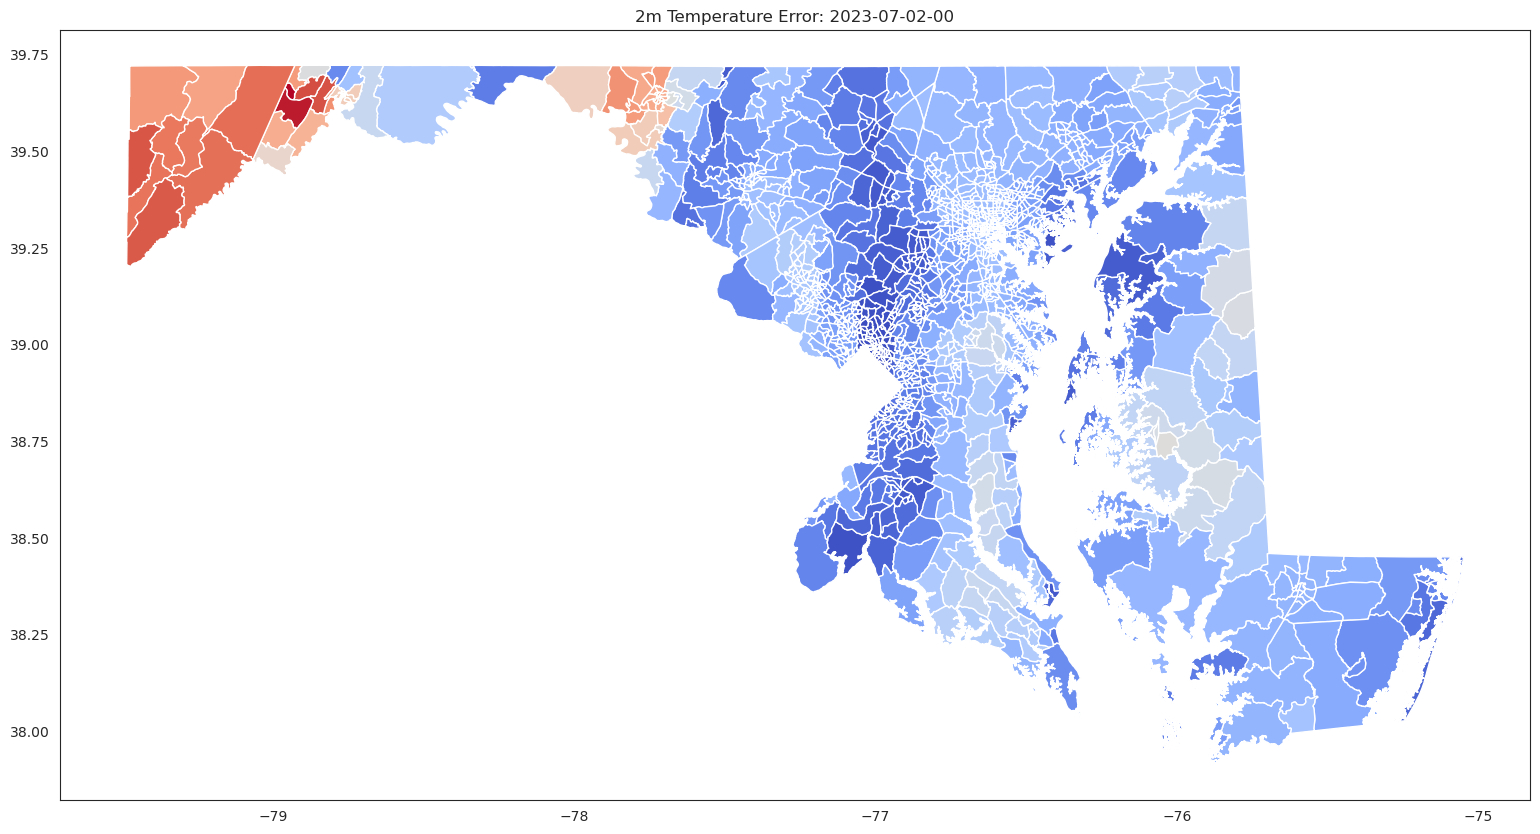

In [56]:
fig, ax = plt.subplots(1, figsize=(20,10))
gdf_error[gdf_error['time'] == gdf_error['time'].iloc[0]].plot(column='t2m_abs_error', cmap='coolwarm', ax=ax)
plt.title(f'2m Temperature Error: {gdf_error['time'].values[0]}')
plt.show()

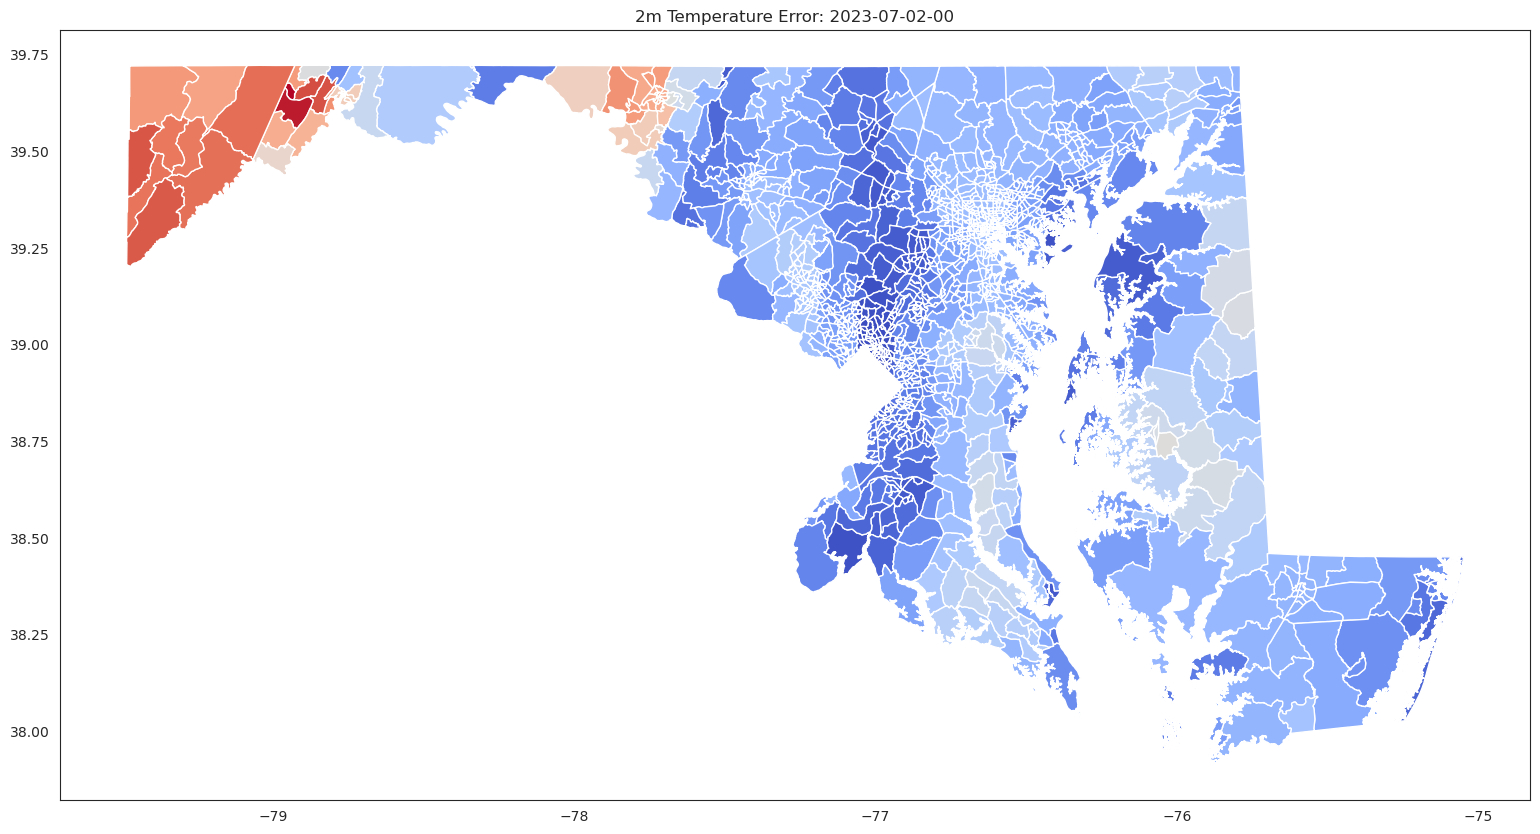

In [57]:
fig, ax = plt.subplots(1, figsize=(20,10))
gdf_error[gdf_error['time'] == gdf_error['time'].iloc[20]].plot(column='t2m_abs_error', cmap='coolwarm', ax=ax)
plt.title(f'2m Temperature Error: {gdf_error['time'].values[20]}')
plt.show()

In [58]:
gdf_error['time'].iloc[20]

'2023-07-02-00'